# Inlämningsuppgift – Klassificera ansiktsuttryck med neurala nätverk

Syftet med uppgiften är att använda neurala nätverk för att bygga en modell som kan klassificera ansiktsuttryck från bilder. Uppgiften avser att bygga en fungerande modell, träna den, utvärdera, förstå hur olika komponenter påverkar resultatet samt göra prediktioner på ny data. 

**Data:** För uppgiften används datasetet *FER-2013*, som innehåller gråskalebilder (48x48 pixlar) av olika ansiktsutryck.

### Uppgiften innehåller:
1. Nödvändiga importer
2. Ladda och utforska datasetet
3. Dataförberedelser
4. Bygger, tränar och utvärderar en modell
5. Testar och förbättrar modellen
5. Gör prediktioner på ny data
6. Analys av resultat

## 1) Importer

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2) Ladda och utforska datan

In [2]:
# Laddar in datan

train_folder = "data/FER-2013/train"
test_folder = "data/FER-2013/test"

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

def load_fer2013_data(folder, class_names):
    images = []
    labels = []

    for label, class_name in enumerate(class_names):
        class_folder = folder + "/" + class_name

        for image_name in os.listdir(class_folder):
            image_file = class_folder + "/" + image_name

            image = load_img(
                image_file,
                color_mode="grayscale",
                target_size=(48, 48)
            )

            image = img_to_array(image)
            image = image.squeeze()

            images.append(image)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels


train_images_full, train_labels_full = load_fer2013_data(train_folder, class_names)
test_images, test_labels = load_fer2013_data(test_folder, class_names)

In [3]:
print("Bilder i train set:", train_images_full.shape)
print("Bilder i test set:", test_images.shape)
print("Bilder totalt:", len(train_labels_full) + len(test_labels))
print("Klasser:", np.unique(test_labels))

Bilder i train set: (28709, 48, 48)
Bilder i test set: (7178, 48, 48)
Bilder totalt: 35887
Klasser: [0 1 2 3 4 5 6]


### 2.1 Summering av dataset

- Datasetet innehåller 35,887 bilder där varje bild representeras i 48 x 48 pixels var.
- Datasetet är indelat i train-set - 28,709 bilder och test-set - 7,178. 
- Det finns 7 klasskategorier eller *labels* som bilderna kan hamna inom - *labels* är en vektor av integers från 0 till 6. Dessa representerar vilken sort av ansiktsuttryck bilder hamnar inom:

| Label       | Class       |
| ----------- | ----------- |
| 0 	      |  angry      |
| 1 	      |  disgust    |
| 2 	      |  fear       |
| 3 	      |  happy      |
| 4 	      |  neutral    |
| 5 	      |  sad        |
| 6 	      |  surprise   |

### 2.2 Klassfördelning

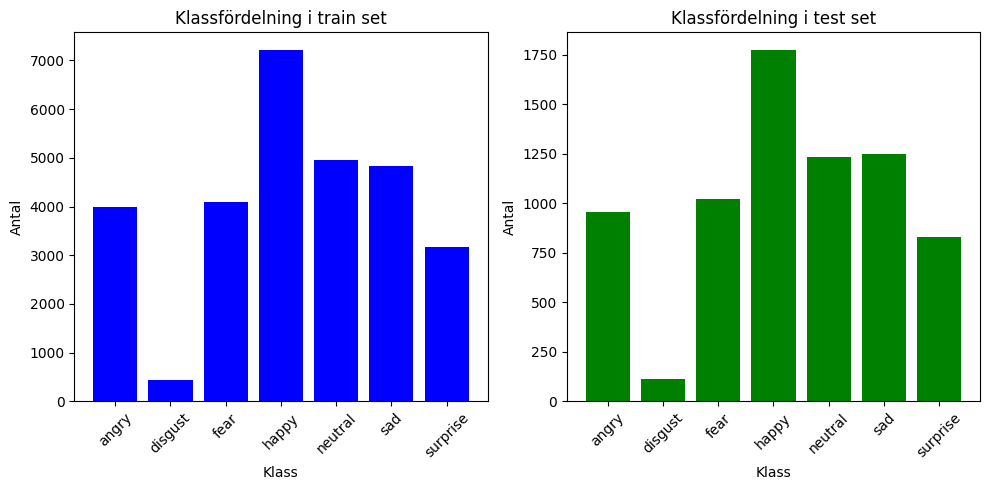

In [4]:
# Identifierar eventuella obalanser

classes_train, counts_train = np.unique(train_labels_full, return_counts=True)
classes_test, counts_test = np.unique(test_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color='blue')
axes[0].set_title('Klassfördelning i train set')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')
axes[0].set_xticks(classes_train)
axes[0].set_xticklabels(class_names, rotation=45)

axes[1].bar(classes_test, counts_test, color='green')
axes[1].set_title('Klassfördelning i test set')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')
axes[1].set_xticks(classes_test)
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

Datasetet är **obalanserat**, där vissa klasser förekommer betydligt oftare än andra. För att minska träningstiden och göra klassfördelningen jämnare skapar jag därför ett balanserat subset med lika många bilder från varje klass längre fram i projektet.

### 2.3 Exempelbilder

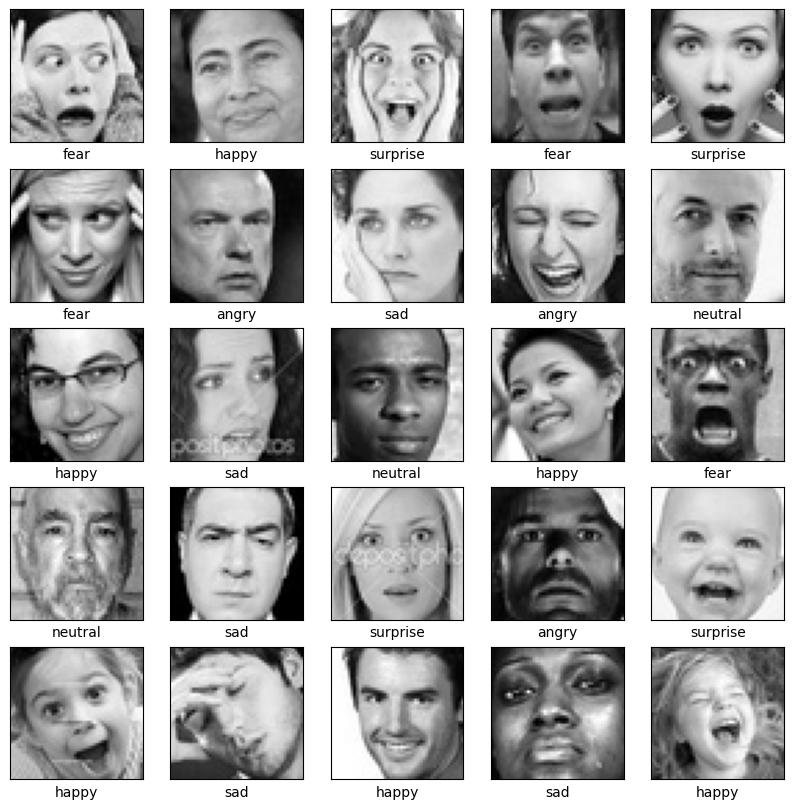

In [5]:
# Visar exempelbilder från träningsdatan

plt.figure(figsize=(10,10))

random_pictures = np.random.choice(len(train_images_full), size=25, replace=False)

for i, index in enumerate(random_pictures):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_full[index], cmap="gray")
    plt.xlabel(class_names[train_labels_full[index]])

plt.show()

## 3) Dataförberedelser

### 3.1 Funktion som skapar ett balanserat subset

Ett subset kommer att användas under utveckling för snabbare iterationer. Subsetet väljer ut 400 samples från varje klass. 

In [6]:
def create_balanced_subset(X, y, samples_per_class=400, random_state=42):

    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    train_images_full,
    train_labels_full,
    samples_per_class=400,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset_raw: (2800, 48, 48)
y_subset: (2800,)


För att minska träningstiden använder jag ett balanserat subset av träningsdatan med 400 bilder per klass. Testdatan behölls däremot i sin helhet för att modellen skulle kunna utvärderas på hela testmängden.

### 3.2 Train/Validation-split

Träningsdatan delas upp i train (80 %) och validation (20 %). 

In [7]:
train_images, val_images, train_labels, val_labels = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("Train images:", train_images.shape)
print("Validation images:", val_images.shape)
print("Train labels:", train_labels.shape)
print("Validatio labels:", val_labels.shape)

Train images: (2240, 48, 48)
Validation images: (560, 48, 48)
Train labels: (2240,)
Validatio labels: (560,)


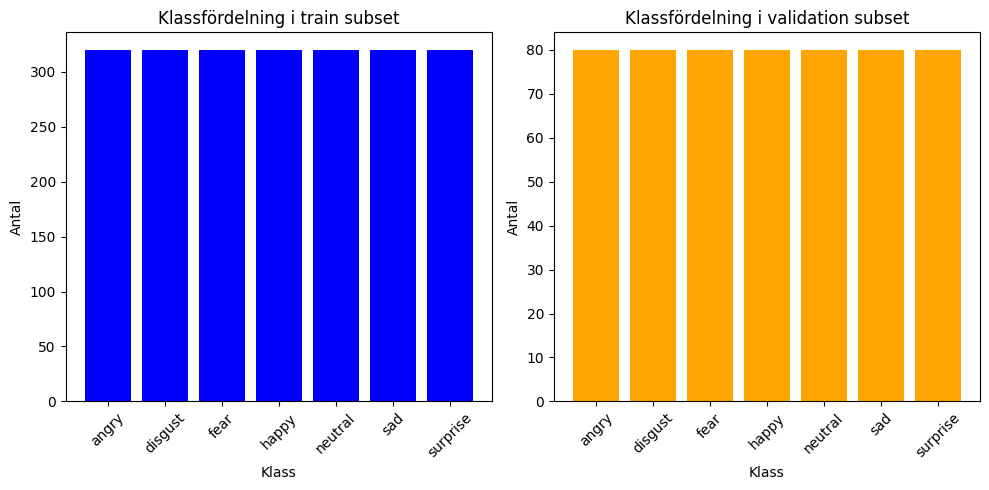

In [8]:
# Kontrolerar klassfördelning efter min split:

classes_train, counts_train = np.unique(train_labels, return_counts=True)
classes_val, counts_val = np.unique(val_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color='blue')
axes[0].set_title('Klassfördelning i train subset')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')
axes[0].set_xticks(classes_train)
axes[0].set_xticklabels(class_names, rotation=45)

axes[1].bar(classes_val, counts_val, color='orange')
axes[1].set_title('Klassfördelning i validation subset')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')
axes[1].set_xticks(classes_val)
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Normalisering

In [9]:
train_images_norm = train_images / 255.0
val_images_norm = val_images / 255.0
test_images_norm = test_images / 255.0

print("Train imgs min/max:", train_images_norm.min(), train_images_norm.max())
print("Validation imgs min/max:", val_images_norm.min(), val_images_norm.max())
print("Test imgs shape:", test_images_norm.shape)

Train imgs min/max: 0.0 1.0
Validation imgs min/max: 0.0 1.0
Test imgs shape: (7178, 48, 48)


### 3.4 Kontrollerar form på kanaldimension

In [10]:
# Anpassar bildformatet för CNN

train_images_norm = train_images_norm[..., np.newaxis]
val_images_norm = val_images_norm[..., np.newaxis]
test_images_norm = test_images_norm[..., np.newaxis]

print("Train imgs shape efter kanal-dimension:", train_images_norm.shape)
print("Validation imgs shape efter kanal-dimension:", val_images_norm.shape)
print("Test imgs shape efter kanal-dimension:", test_images_norm.shape)

Train imgs shape efter kanal-dimension: (2240, 48, 48, 1)
Validation imgs shape efter kanal-dimension: (560, 48, 48, 1)
Test imgs shape efter kanal-dimension: (7178, 48, 48, 1)


## 4) Baseline modell

### 4.1 Bygger och kompilerar en baseline CNN-model

Skapar en baseline-modell med CNN-arkitektur. Modellen består av två convolutional layers (Conv2D) som används för att identifiera mönster i bilderna, följt av max pooling som minskar bilddimensionerna. Därefter används ett flatten-lager och dense-lager för klassificering. Det sista lagret har 7 neuroner eftersom datasetet innehåller 7 klasser. Softmax används för att modellen ska ge sannolikheter för varje klass.

In [11]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),       # 64 neuroner 
        layers.Dense(7, activation="softmax")      # 7 klassser
    ])
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
    )
    
    return model

In [12]:
baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,159 (2.32 MB)

 Trainable params: 609,159 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Träna baseline

Efter att baseline-modellen har byggts och compile:ats tränas den på normaliserade träningsdata. 
Jag använder validation data för att kunna följa hur modellen presterar på data som den inte tränas direkt på.

I den första baseline använder jag 5 epochs och batch size 32. 
Resultatet sparas i `history_baseline`, vilket gör att man senare kan visualisera utvecklingen av loss och accuracy under träningen.

In [13]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_images_norm,
    train_labels,
    validation_data = (val_images_norm, val_labels),
    epochs=5,
    batch_size=32
)

baseline_trainig_time = time.time() - start_time

print(f"Träningstid för baseline på subset: {baseline_trainig_time / 60:.2f} minuter")

Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.1589 - loss: 1.9505 - val_accuracy: 0.1446 - val_loss: 1.9417
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.2018 - loss: 1.9122 - val_accuracy: 0.2482 - val_loss: 1.8640
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.2964 - loss: 1.7939 - val_accuracy: 0.2732 - val_loss: 1.8289
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3594 - loss: 1.6898 - val_accuracy: 0.2964 - val_loss: 1.8005
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4121 - loss: 1.5876 - val_accuracy: 0.3357 - val_loss: 1.7753
Träningstid för baseline på subset: 0.28 minuter


### 4.3 Träningskurvor för loss och accuracy

In [14]:
# Funktion för att plotta träningskurvor för loss och accuracy.

def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.grid(True)
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.grid(True)
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

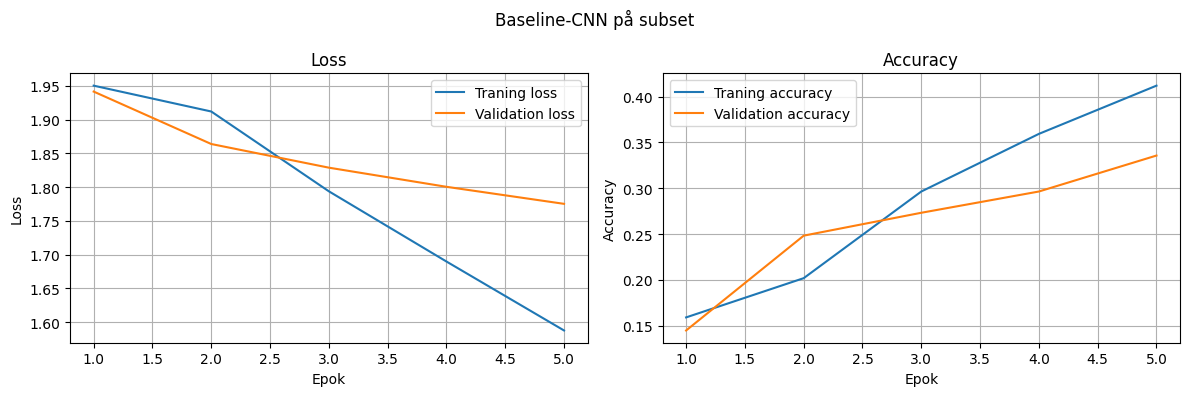

In [15]:
plot_history(history_baseline, title="Baseline-CNN på subset")

Modellen förbättras under träningen, då **training accuracy ökar och training loss minskar**. Även validation accuracy ökar, vilket visar att modellen lär sig mönster som delvis fungerar på ny data. 
Samtidigt ser jag att validation accuracy är lägre än training accuracy, vilket tyder på att modellen har svårare att generalisera och att det finns vissa **tecken på overfitting**. Eftersom detta är en enkel baseline-modell tränad på ett mindre subset är resultatet ändå en rimlig såhär i början.

### 4.4 Validation accuracy

In [16]:
def predict_classes(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

In [17]:
baseline_val_pred, baseline_val_proba = predict_classes(
    baseline_model,
    val_images_norm
)

baseline_val_accuracy = accuracy_score(val_labels, baseline_val_pred)

print(f"Baseline validation accuracy: {baseline_val_accuracy:.4f}")

Baseline validation accuracy: 0.3357


In [18]:
history_baseline_df = pd.DataFrame(history_baseline.history)

best_epoch = history_baseline_df["val_loss"].idxmin() + 1
best_val_loss = history_baseline_df["val_loss"].min()
best_val_accuracy = history_baseline_df["val_accuracy"].iloc[best_epoch - 1]

print(f"Bästa validation loss vid epok: {best_epoch}")
print(f"Bästa validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy vid den epoken: {best_val_accuracy:.4f}")

Bästa validation loss vid epok: 5
Bästa validation loss: 1.7753
Validation accuracy vid den epoken: 0.3357


### 4.5 Confusion Matrix

In [19]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
        cmap="Oranges",
        colorbar=False
    )

    ax.set_xlabel("Predicted label", fontsize=14)
    ax.set_ylabel("True label", fontsize=14)

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

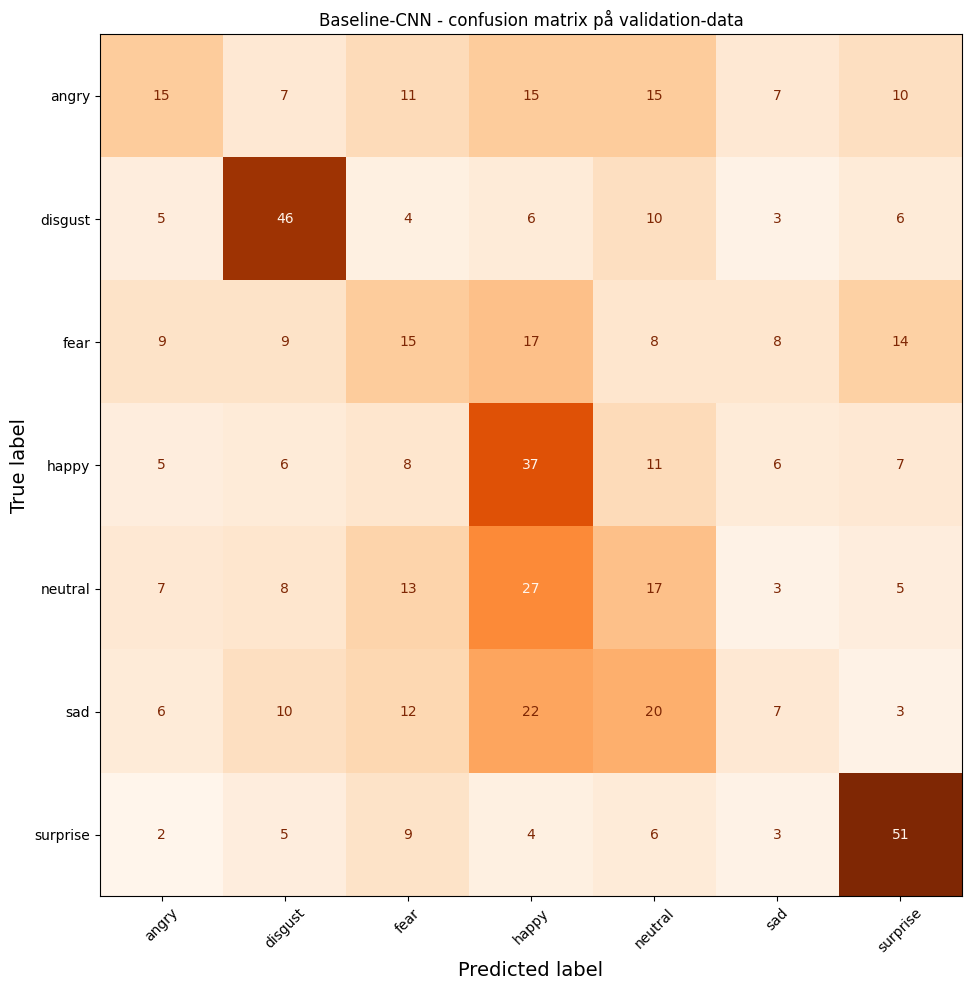

In [20]:
baseline_cm = plot_confusion_matrix(
    val_labels,
    baseline_val_pred,
    class_names,
    title="Baseline-CNN - confusion matrix på validation-data"
)

Confusion matrixen visar att modellen klassificerar `surprise` och `disgust` bäst, med **51 respektive 46 korrekta prediktioner av 80**. Klassen `happy` fungerar också något bättre än flera andra klasser. Däremot har modellen **svårt att skilja mellan** `angry`, `fear`, `neutral` och `sad`, som ofta blandas ihop med andra uttryck. Detta visar att modellen har lärt sig vissa tydliga mönster, men att den fortfarande har svårt att separera mer lika eller subtila ansiktsuttryck.

#### 4.6 Accuracy per klass

In [21]:
def calculate_per_classs_accuracy(cm, class_names):

    support = cm.sum(axis=1)
    korrekta = np.diag(cm)

    accuracy = np.divide(
        korrekta,
        support,
        out=np.zeros_like(korrekta, dtype=float),
        where=support != 0
    )

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": korrekta,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")

In [22]:
baseline_per_class = calculate_per_classs_accuracy(
    baseline_cm,
    class_names
)

baseline_per_class

,class_id,class_name,support,correct,accuracy
5,5,sad,80,7,0.0875
0,0,angry,80,15,0.1875
2,2,fear,80,15,0.1875
4,4,neutral,80,17,0.2125
3,3,happy,80,37,0.4625
1,1,disgust,80,46,0.5750
6,6,surprise,80,51,0.6375


Tabellen visar att modellens resultat varierar mycket mellan klasserna. `Surprise` och `disgust` **klassificeras bäst**, med accuracy på cirka 0.64 respektive 0.58. Klassen `happy` fungerar också bättre än flera andra klasser. Däremot har modellen **svårt med framför allt** `sad`, `angry` och `fear`, där accuracy är låg. Detta tyder på att baseline-modellen har lättare att känna igen tydligare uttryck men svårare att skilja mellan mer lika eller subtila ansiktsuttryck.

### 4.7 Vanligaste förväxlingarna

In [23]:
# Hjälpfunktion: Bildexempel på vanligaste förväxlingarna 

def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names,
    n_images=18,
    random_state=42
):
    """
    Visar felklassificerade bilder.

    X:
        Bilddata, normaliserad eller i 0-1-format.

    y_true:
        Sanna labels.

    y_pred:
        Predikterade labels.

    y_proba:
        Sannolikheter från modellen.

    class_names:
        Lista med klassnamn.

    n_images:
        Antal felklassificerade bilder att visa.

    random_state:
        Seed för reproducerbart urval.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Totalt antal felklassificerade bilder: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade bilder att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 6
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index].squeeze(), cmap="gray")
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Totalt antal felklassificerade bilder: 372


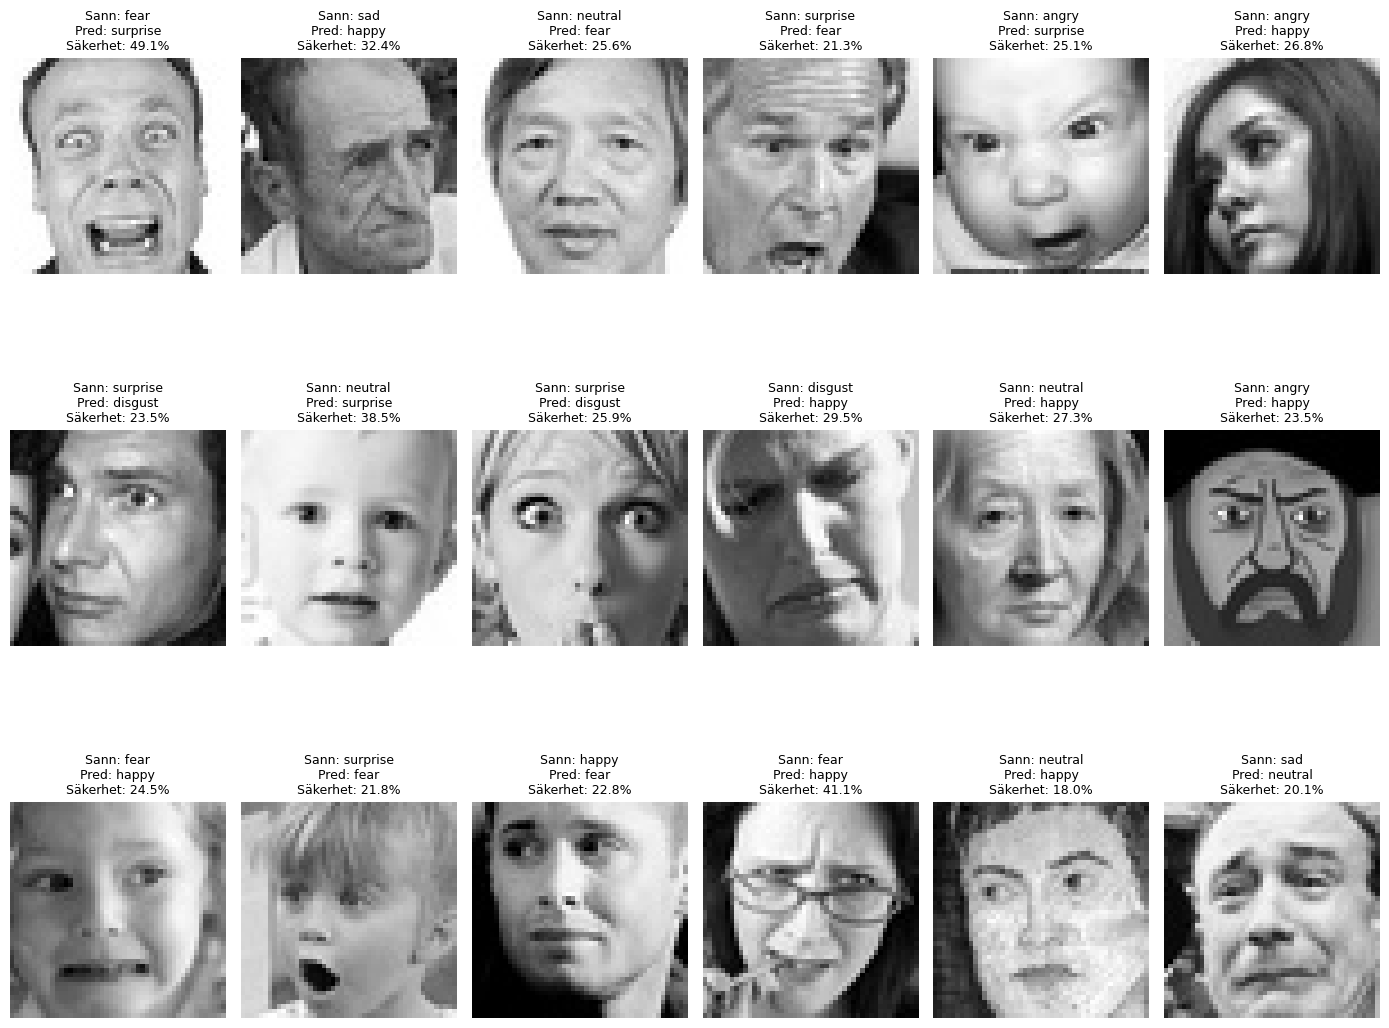

In [24]:
plot_misclassified_examples(
    val_images_norm,
    val_labels,
    baseline_val_pred,
    baseline_val_proba,
    class_names,
    n_images=18,
    random_state=42
)

De felklassificerade bilderna (372 st) visar att modellen ofta blandar ihop uttryck som liknar varandra, till exempel `fear`, `surprise`, `sad` och `neutral`. Vissa fel är förståeliga eftersom bilderna är lågupplösta eller otydliga, men modellen missar även uttryck som verkar tydliga med blott öga. Det är rimligt för en enkel baseline-modell tränad på ett begränsat subset, eftersom modellen bara lär sig pixelmönster och inte tolkar ansiktsuttryck på samma sätt som en människa.

## 5) Testa och förbättra modellen

Jag har nu en fungerande baseline-modell med en `val_accuracy` på ~ 34 %. Nästa steg är att systematiskt förbättra den.

För att hantera träningen använder jag två hjälpfunktioner:
- `apply_early_stopping()` stoppar träningen automatiskt när `val_loss` inte förbättras med mer än 0.001 på n epocher och återställer de bästa vikterna.  
- `train_model()` kör träningen med valfria `epochs`, `batch_size` och `patience` och skriver ut bästa `epoch`, `val_accuracy`, `val_loss` samt träningstid.  

In [25]:
def build_and_compile_improved_model():
    """
    Bygger en förbättrad CNN-modell med fler convolutional layers och dropout.
    Dropout används för att minska risken för overfitting.
    """

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = keras.Sequential([

        layers.Input(shape=(48, 48, 1)),

        # Block 1
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),

        layers.Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

In [26]:
model_2_improved = build_and_compile_improved_model()
model_2_improved.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

### 5.1 Hjälpfunktioner för träning

In [27]:
def apply_early_stopping():
    """
    Stoppar träningen när val_loss inte förbättras.
    Återställer automatiskt de bästa vikterna.
    """

    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        min_delta=0.001
    )

In [28]:
def train_model(model, model_name="model", epochs=20, batch_size=32):
    """
    Tränar en modell med vald epochs och batch_size.
    """

    print(f"Träning av {model_name}: epochs = {epochs}, batch_size = {batch_size}")

    history = model.fit(
        train_images_norm,
        train_labels,
        validation_data=(val_images_norm, val_labels),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[apply_early_stopping()]
    )

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    val_loss, val_accuracy = model.evaluate(
        val_images_norm,
        val_labels,
        verbose=0
    )

    print(f"\nBästa resultat för {model_name}:")
    print(f"Bästa epoch:  {best_epoch}")
    print(f"Val accuracy: {val_accuracy:.4f}")
    print(f"Val loss:     {val_loss:.4f}")

    return history

### 5.2 Tränar förbättrad modell

In [29]:
history_model_2 = train_model(
    model_2_improved,
    model_name="model_2_improved",
    epochs=20,
    batch_size=32
)

Träning av model_2_improved: epochs = 20, batch_size = 32
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.1348 - loss: 1.9511 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.1464 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - accuracy: 0.1379 - loss: 1.9461 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.1330 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.1420 - loss: 1.9462 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.1379 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459

Bästa resultat för model_2_improved:
Bästa epoch:  1
Val accuracy: 0.1429
Val loss:     1.9459


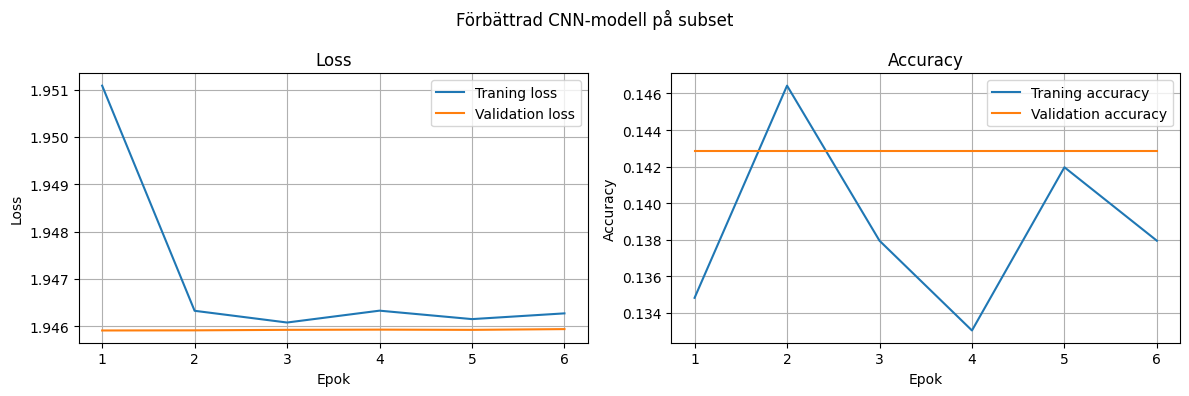

In [30]:
plot_history(history_model_2, title="Förbättrad CNN-modell på subset")

Den förbättrade CNN-modellen verkar **inte lära sig så bra**. Loss ligger nästan stilla och validation loss förändras knappt under träningen. Accuracy ligger också väldigt lågt och validation accuracy är nästan helt rak.

Det tyder på att **modellen inte förbättras särskilt mycket under träningen**. Den verkar snarare ha svårt att hitta tydliga mönster i bilderna. Därför fungerar den förbättrade modellen sämre än baseline-modellen i detta försök.

### 5.3 Utvärdera förbättrad modell på min testdata

In [31]:
model_2_val_pred, model_2_val_proba = predict_classes(
    model_2_improved,
    val_images_norm
)

model_2_val_accuracy = accuracy_score(val_labels, model_2_val_pred)

print(f"Baseline validation accuracy: {baseline_val_accuracy:.4f}")
print(f"Model 2 validation accuracy: {model_2_val_accuracy:.4f}")

Baseline validation accuracy: 0.3357
Model 2 validation accuracy: 0.1429


### 5.4 Test av tredje modell

Eftersom den första förbättrade modellen presterade sämre än baseline-modellen testar jag en tredje modellvariant. Syftet är att se om en annan arkitektur kan ge bättre resultat. Denna modell använder BatchNormalization och mindre dropout för att försöka göra träningen mer stabil.

In [32]:
def build_and_compile_model_3():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

In [33]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_3 = build_and_compile_model_3()

history_model_3 = model_3.fit(
    train_images_norm,
    train_labels,
    validation_data=(val_images_norm, val_labels),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.1643 - loss: 2.1924 - val_accuracy: 0.1429 - val_loss: 6.7321
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.1888 - loss: 1.9187 - val_accuracy: 0.1429 - val_loss: 10.4425
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.2527 - loss: 1.8267 - val_accuracy: 0.1429 - val_loss: 12.4812
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.3089 - loss: 1.7449 - val_accuracy: 0.1429 - val_loss: 9.8099
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.3415 - loss: 1.6722 - val_accuracy: 0.1500 - val_loss: 6.0322
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.3964 - loss: 1.5431 - val_accuracy: 0.1500 - val_loss: 3.8173
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.4563 - loss: 1.4105 - val_accuracy: 0.1982 - val_loss: 2.4164
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.5103 - loss: 1.2800 - val_accuracy:

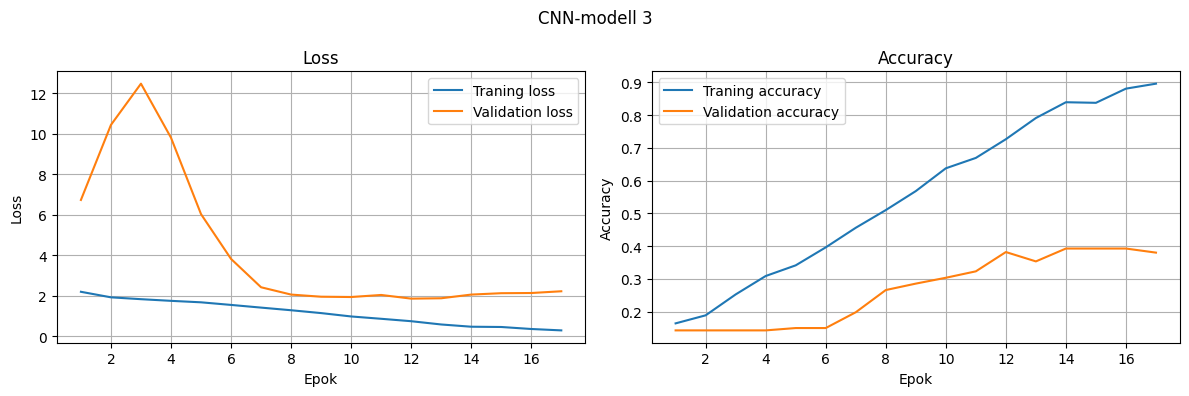

In [34]:
plot_history(history_model_3, title="CNN-modell 3")

In [35]:
model_3_val_pred, model_3_val_proba = predict_classes(
    model_3,
    val_images_norm
)

model_3_val_accuracy = accuracy_score(val_labels, model_3_val_pred)

print(f"Model 3 validation accuracy: {model_3_val_accuracy:.4f}")

Model 3 validation accuracy: 0.3821


### 5.5 Jämföra alla tre modeller

In [36]:
validation_comparison = pd.DataFrame({
    "model": ["Baseline CNN", "Improved CNN", "Model 3 CNN"],
    "validation_accuracy": [
        baseline_val_accuracy,
        model_2_val_accuracy,
        model_3_val_accuracy
    ]
})

validation_comparison

,model,validation_accuracy
0,Baseline CNN,0.335714
1,Improved CNN,0.142857
2,Model 3 CNN,0.382143


**Model 3 CNN presterade bäst** på validation data med en accuracy på cirka **38,2 %**. Baseline CNN fick cirka **33,6 %**, medan Improved CNN bara fick cirka **14,3 %**.

Resultatet visar att den första förbättrade modellen inte blev bättre bara för att den var mer komplex. Den kan ha haft för mycket dropout eller varit för svår att träna på det begränsade subsetet. Model 3 fungerade bättre, troligen eftersom den använde BatchNormalization och mindre dropout. Därför väljs Model 3 CNN som final model.

### 5.6 Välja final model

In [37]:
models = {
    "Baseline CNN": baseline_model,
    "Improved CNN": model_2_improved,
    "Model 3 CNN": model_3
}

accuracies = {
    "Baseline CNN": baseline_val_accuracy,
    "Improved CNN": model_2_val_accuracy,
    "Model 3 CNN": model_3_val_accuracy
}

final_model_name = max(accuracies, key=accuracies.get)
final_model = models[final_model_name]

print(f"Vald final model: {final_model_name}")
print(f"Validation accuracy: {accuracies[final_model_name]:.4f}")

Vald final model: Model 3 CNN
Validation accuracy: 0.3821


### 5.7 Slutlig utvärdering på testdata

In [38]:
test_loss, test_accuracy = final_model.evaluate(
    test_images_norm,
    test_labels,
    verbose=0
)

print(f"Final model: {final_model_name}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Final model: Model 3 CNN
Test loss: 1.8844
Test accuracy: 0.3621


**Model 3 CNN valdes som final model och fick cirka 36,2 % accuracy på testdatan.** Det visar att modellen har lärt sig vissa mönster, men att den fortfarande gör många fel. Resultatet är bättre än slumpmässig gissning, men modellen är inte tillräckligt säker för att klassificera alla känslor korrekt.

### 5.8 Confusion matrix på testdata

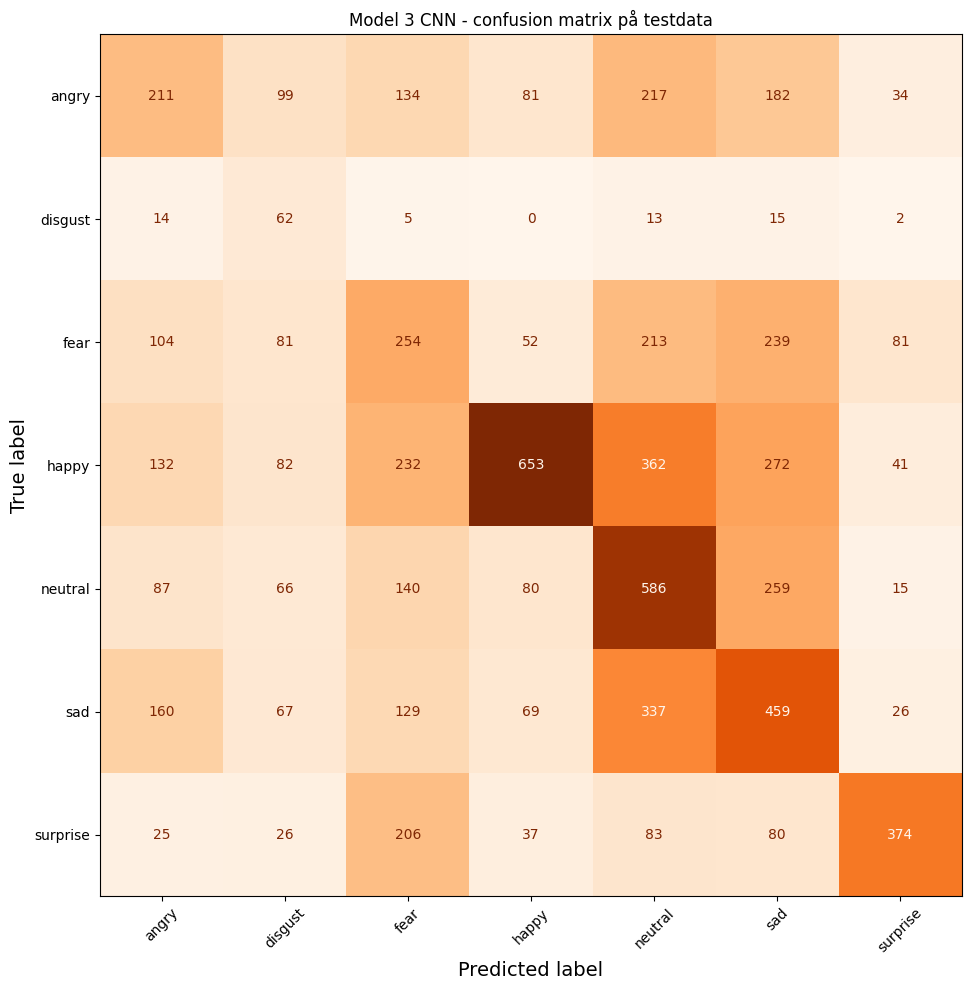

In [39]:
test_pred, test_proba = predict_classes(
    final_model,
    test_images_norm
)

test_cm = plot_confusion_matrix(
    test_labels,
    test_pred,
    class_names,
    title=f"{final_model_name} - confusion matrix på testdata"
)

Confusion matrix visar att modellen **klarar vissa klasser bättre än andra**. Den får flest rätt på bland annat `neutral`, `disgust` och `surprise`, men blandar ofta ihop klasser som `sad`, `fear`, `angry` och `happy`. Det tyder på att vissa ansiktsuttryck är svåra att skilja åt, särskilt när de liknar varandra och är svåra även för oss människor att skilja åt med blott öga.

### 5.9 Accuracy per klass på testdata

In [40]:
test_per_class = calculate_per_classs_accuracy(
    test_cm,
    class_names
)

test_per_class

,class_id,class_name,support,correct,accuracy
0,0,angry,958,211,0.220251
2,2,fear,1024,254,0.248047
5,5,sad,1247,459,0.368083
3,3,happy,1774,653,0.368095
6,6,surprise,831,374,0.450060
4,4,neutral,1233,586,0.475264
1,1,disgust,111,62,0.558559


Accuracy per klass visar att **modellen inte presterar lika bra på alla känslor**. Den bästa klassen är `disgust`, med cirka **55,9 %** accuracy, följt av `neutral` med cirka 47,5 % och `surprise` med cirka 45,0 %.

Modellen har svårast för `angry` och `fear`, där accuracy ligger runt 22–25 %. Det betyder att modellen ofta blandar ihop dessa känslor med andra klasser.

Detta visar att den totala accuracy inte ger hela bilden. Även om modellen får cirka 36,2 % totalt, finns det stora skillnader mellan klasserna.

### Liten felanalys - felklassificerade bilder

Totalt antal felklassificerade bilder: 4579


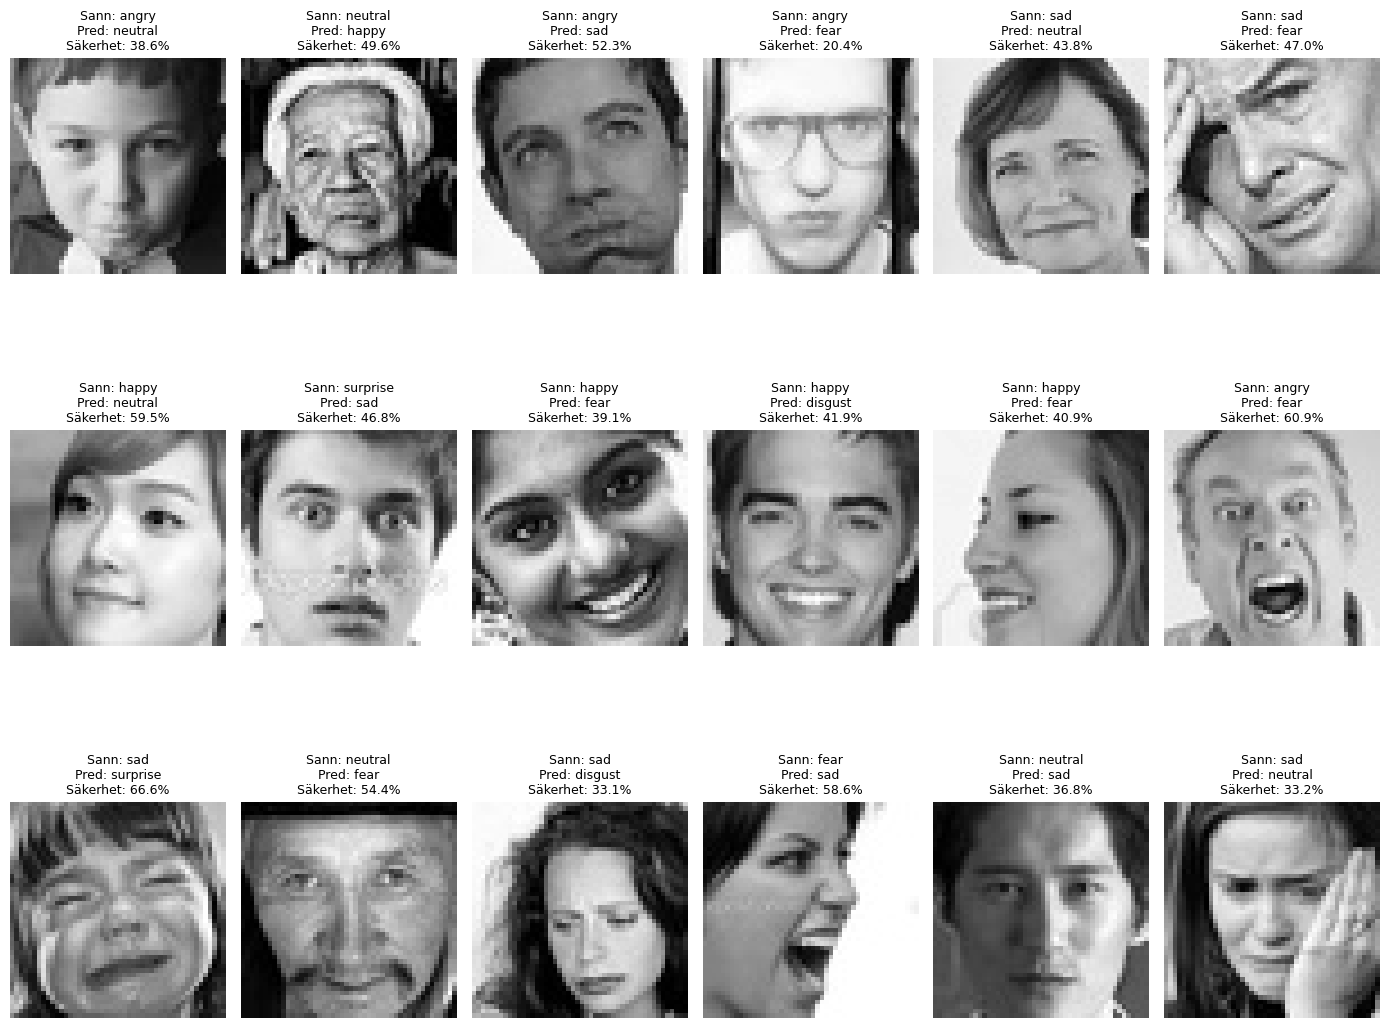

In [41]:
plot_misclassified_examples(
    test_images_norm,
    test_labels,
    test_pred,
    test_proba,
    class_names,
    n_images=18,
    random_state=42
)

Modellen gör **många felklassificeringar** (4579 st). Exempelbilderna visar att flera bilder är svåra att tolka eftersom ansiktsuttrycken ibland är otydliga även för oss människor att förstå eller liknar andra känslor. Detta kan förklara varför modellen blandar ihop vissa klasser.

## 6) Gör prediktioner på ny bild

### 6.1 Ladda in min egna bild

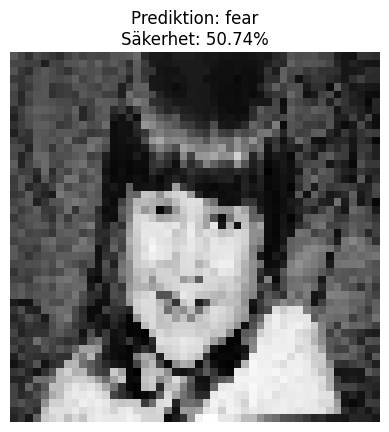

In [43]:
# Sökväg till min egna bild
image_path = "data/my_image.jpg"

# Laddar in bilden på samma sätt som träningsbilderna
img = image.load_img(
    image_path,
    color_mode="grayscale",
    target_size=(48, 48)
)

# Gör om bilden till array
img_array = image.img_to_array(img)

# Normaliserar bilden, precis som jag gjorde med träningsdatan
img_array_norm = img_array / 255.0

# Lägger till batch-dimension: (1, 48, 48, 1)
img_for_prediction = np.expand_dims(img_array_norm, axis=0)

# Gör prediktion med den valda final model
prediction = final_model.predict(img_for_prediction, verbose=0)

# Hämtar klassen med högst sannolikhet
predicted_label = np.argmax(prediction)
confidence = np.max(prediction)

# Visar bilden och resultatet
plt.imshow(img_array_norm.squeeze(), cmap="gray")
plt.axis("off")
plt.title(
    f"Prediktion: {class_names[predicted_label]}\n"
    f"Säkerhet: {confidence:.2%}"
)
plt.show()

### 6.2 Visa orginalbild

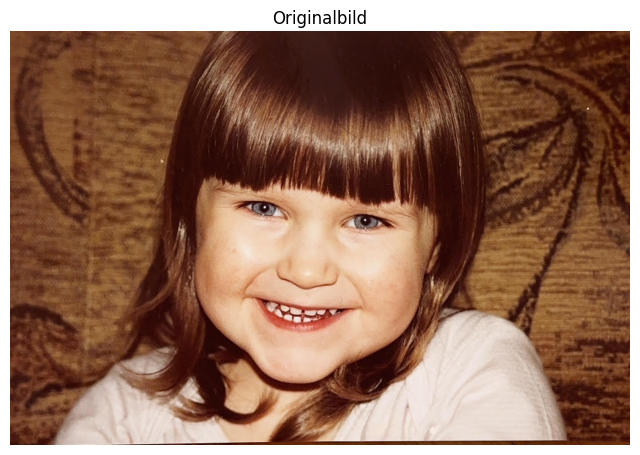

In [45]:
original_image_path = "data/my_image.jpg"

original_img = mpimg.imread(original_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(original_img)
plt.axis("off")
plt.title("Originalbild")
plt.show()

### 6.3 Prediktion på egen bild- resultat

Jag testade modellen på en egen bild (min syster när hon var liten) som inte fanns med i träningsdatan. Modellen predikterade klassen `fear` med cirka **50,7 % säkerhet**.

Den riktiga känslan i bilden räknar jag som `happy`, eftersom min syster ler. **Modellen predikterade alltså fel i detta exempel**.

En möjlig anledning är att bilden ändras ganska mycket innan den skickas in i modellen. Den görs om till gråskala och minskas till 48x48 pixlar, vilket gör att många detaljer försvinner. Ansiktet blir mer pixligt och modellen kan därför ha svårt att tolka uttrycket rätt.

### 6.4 Ett till försök på ännu svårare bildexempel

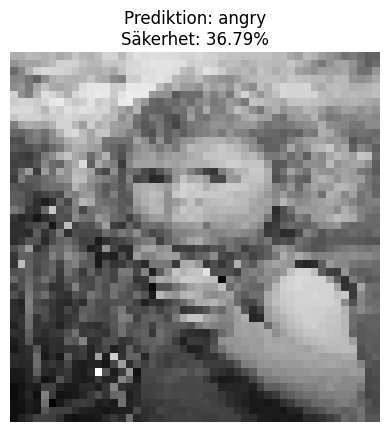

In [47]:
image_path = "data/my_image_2.jpg"

img = image.load_img(
    image_path,
    color_mode="grayscale",
    target_size=(48, 48)
)

img_array = image.img_to_array(img)
img_array_norm = img_array / 255.0
img_for_prediction = np.expand_dims(img_array_norm, axis=0)
prediction = final_model.predict(img_for_prediction, verbose=0)

predicted_label = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(img_array_norm.squeeze(), cmap="gray")
plt.axis("off")
plt.title(
    f"Prediktion: {class_names[predicted_label]}\n"
    f"Säkerhet: {confidence:.2%}"
)
plt.show()

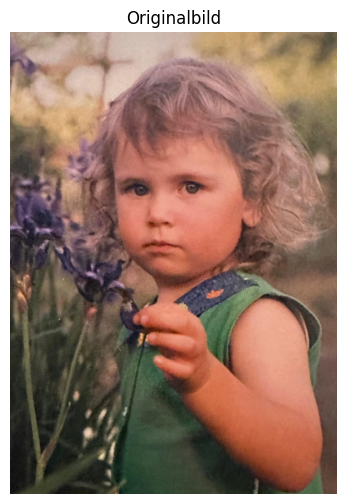

In [48]:
original_image_path = "data/my_image_2.jpg"

original_img = mpimg.imread(original_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(original_img)
plt.axis("off")
plt.title("Originalbild")
plt.show()

Den här bilden (bild på mig själv när jag var liten) är svår att klassificera även manuellt. Jag tolkar den mest som `neutral`, men modellen predikterade `angry`. Det kan bero på att ansiktsuttrycket är allvarligt och att bilden blir mycket pixlig när den ändras till 48x48 pixlar. Modellens säkerhet är dessutom låg, vilket visar att prediktionen är osäker.

## 7) Analysera resultatet

### Hur bra fungerar modellen?
Min final model blev Model 3 CNN. Den fick cirka **36,2 % accuracy på testdatan**, vilket betyder att modellen fungerar bättre än slumpmässig gissning men fortfarande gör många fel.

### Overfitting/underfitting
Jag ser inte tydliga tecken på stark overfitting, eftersom validation accuracy och test accuracy ligger ganska nära varandra. Validation accuracy var cirka **38,2 %** och test accuracy cirka **36,2 %**. Däremot verkar modellen ha svårt att lära sig tillräckligt bra mönster, vilket kan tyda på viss underfitting eller att problemet är svårt.

### Vad påverkade resultatet?
Det som påverkar resultatet mest är troligen att bilderna är små, bara 48x48 pixlar, gråskaliga och ibland otydliga som gör att ansiktsuttryck kan vara svåra att skilja åt. De kan också vara svåra att tolka även för en människa med blott öga. En begränsning är därför att modellen inte är tillräckligt säker på mer otydliga bilder, särskilt när uttrycken liknar varandra.
En annan faktor är att jag tränade modellen på ett mindre balanserat subset med 400 bilder per klass. Det gjorde träningen snabbare och mer hanterbar, men modellen fick också mindre data att lära sig från.

### Skillnad mellan träningsdata, validation data och testdata
Modellen tränades på träningsdatan och jämfördes sedan med validation data under modellutvecklingen. Validation accuracy för Model 3 blev cirka **38,2 %**, medan test accuracy blev cirka **36,2 %**. Eftersom resultaten på validation och test ligger ganska nära varandra verkar modellen prestera ungefär liknande på ny data som på validation data.

Det betyder att modellen inte bara fungerar på träningsdatan, men resultatet är fortfarande ganska lågt. Om träningsresultatet hade varit mycket högre än validation och test hade det varit ett tydligare tecken på overfitting. I detta fall verkar problemet snarare vara att modellen har svårt att lära sig tillräckligt bra mönster från bilderna.
 
### Begränsningar
En begränsning med modellen är att den tränades på ett mindre subset med 400 bilder per klass. Det gjorde träningen snabbare, men modellen fick också mindre data att lära sig från.
En annan begränsning är att bilderna är små, gråskaliga och skalas ner till 48x48 pixlar. Det gör att viktiga detaljer i ansiktet kan försvinna. Modellen har också svårt att skilja mellan känslor som liknar varandra, till exempel `angry`, `fear`, `sad` och `neutral`.
Modellen är därför inte tillräckligt säker för att användas på riktigt, men den fungerar som ett enkelt exempel på hur en CNN kan tränas för bildklassificering.

In [49]:
train_accuracy_model_3 = history_model_3.history["accuracy"][-1]
val_accuracy_model_3 = history_model_3.history["val_accuracy"][-1]

print(f"Training accuracy Model 3: {train_accuracy_model_3:.4f}")
print(f"Validation accuracy Model 3: {val_accuracy_model_3:.4f}")
print(f"Test accuracy Model 3: {test_accuracy:.4f}")

Training accuracy Model 3: 0.8964
Validation accuracy Model 3: 0.3804
Test accuracy Model 3: 0.3621


## 8) Reflektion

### Vad var svårast i uppgiften?

Det svåraste i uppgiften var att förstå hela arbetsflödet i det här fallet.  Att först och främst lyckas ladda in externt dataset som vi fick från läraren istället för att ladda ner det direkt från Keras. Det var också svårt att förstå varför en mer avancerad modell inte automatiskt gav bättre resultat. Jag märkte att det inte räcker att bara lägga till fler lager, utan modellen måste också passa datan och tränas på ett bra sätt.

### Vad lärde du dig?

Jag lärde mig hur en CNN kan användas för bildklassificering och hur modellen tränas steg för steg. Jag lärde mig också hur man kan använda träningskurvor, accuracy, confusion matrix och felklassificerade bilder för att analysera resultatet.

En viktig sak jag lärde mig är att deep learning ofta handlar om att testa, jämföra och justera modeller. **ATT HITTA EN BALANS NÄR DET GÄLLER VAL AV OLIKA METODER OCH PARAMETRAR**. En mer komplex modell är inte alltid bättre, och resultatet påverkas mycket av datan, modellens uppbyggnad och hyperparametrar.

### Vad hade du gjort annorlunda om du började om?

Jag hade velat testa fler inställningar mer systematiskt, till exempel olika batch sizes, learning rates och fler träningsbilder.

Jag hade även velat använda mer data än mitt mindre balanserade subset, eftersom modellen troligen hade kunnat lära sig bättre mönster med fler bilder.

### Vilket betyg motsvarar inlämningen?

Jag tycker att min inlämning uppfyller G krav. Jag byggde och utvärderade en CNN-modell men också testade flera modellvarianter och jämförde deras resultat.
Jag testade några punkter från VG kravet men har full förståelse ifall jag inte uppfyller VG helt till 100%. Deep Learning var definitivt den svåraste kursen och jag behöver verkligen fördjupa mig i ämnet mycket mer. 

Jag testade först en baseline-modell, sedan en förbättrad CNN-modell och därefter Model 3 CNN. Jag undersökte hur olika val, till exempel fler lager, dropout, BatchNormalization och fler epochs, påverkade resultatet. Jag jämförde modellerna med validation accuracy och valde sedan den bästa modellen som final model. Mycket inspiration och kod-exempel fick jag från Gruppuppgiften "Utforskning och fördjupning i neurala nätverk" från denna kurs. 

Jag har också analyserat träningsresultat, test accuracy, confusion matrix, accuracy per klass och felklassificerade bilder. Dessutom har jag diskuterat modellens begränsningar, till exempel att bilderna är små, gråskaliga, ibland otydliga och att modellen tränades på ett mindre subset. Därför tycker jag att arbetet visar både grundläggande och även lite mer fördjupad förståelse för uppgiften.